# Single Index Model

Sharpe's **Single Index Model (SIM)** decomposes each asset's return into a part driven by the market and a part specific to the asset:

$$ R_i = \alpha_i + \beta_i R_m + \epsilon_i, $$

with the corresponding variance decomposition

$$ \underbrace{\sigma_i^2}_{\text{total}} = \underbrace{\beta_i^2 \sigma_m^2}_{\text{systematic}} + \underbrace{\sigma_{\epsilon_i}^2}_{\text{firm-specific}}. $$

Systematic risk is undiversifiable; firm-specific risk vanishes in a sufficiently large, well-spread portfolio. That split is the entire argument for holding many assets rather than one.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter

from portfolio.config import DEFAULT_CONFIG
from portfolio.data import DataIngestion, compute_returns
from portfolio.models import SingleIndexModel

BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, MUTED, GRID = "#1f2933", "#6b7785", "#e3e6ea"

sns.set_theme(style="whitegrid")


ingestion = DataIngestion()
prices = ingestion.get_all_prices()
returns = compute_returns(prices)
market = returns[DEFAULT_CONFIG.market_ticker]

## the market series

The SIM treats the market as the single common factor behind every asset, so the market column earns more scrutiny than the rest. Three diagnostics below: descriptive statistics, rolling 60-day annualized volatility, and the shape of the daily return distribution.

In [2]:
market.describe()

count    298.000000
mean       0.000582
std        0.011499
min       -0.059750
25%       -0.003929
50%        0.000898
75%        0.005800
max        0.095154
Name: ^GSPC, dtype: float64

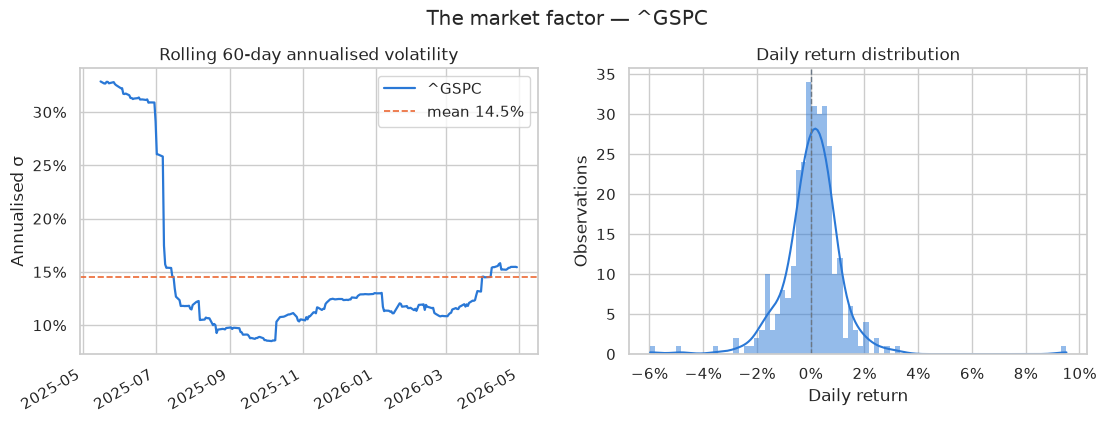

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

rolling_vol = market.rolling(window=60).std() * np.sqrt(252)
rolling_vol.plot(ax=axes[0], color=BLUE, linewidth=1.6)
axes[0].axhline(rolling_vol.mean(), color=ORANGE, linestyle="--", linewidth=1.2,
                label=f"mean {rolling_vol.mean():.1%}")
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
axes[0].set_title("Rolling 60-day annualised volatility")
axes[0].set_ylabel("Annualised σ")
axes[0].set_xlabel("")
axes[0].legend()

sns.histplot(market, bins=80, kde=True, ax=axes[1], color=BLUE, edgecolor="none")
axes[1].axvline(0, color=MUTED, linestyle="--", linewidth=1)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
axes[1].set_title("Daily return distribution")
axes[1].set_xlabel("Daily return")
axes[1].set_ylabel("Observations")

fig.suptitle(f"The market factor — {DEFAULT_CONFIG.market_ticker}", y=1.02)
plt.show()

## Visual intuition — one asset against the market

Plotting one asset's returns against the market's returns and fitting a line gives visual meaning to the regression coefficients. The slope is $\beta$; the intercept is $\alpha$; the vertical distance from each point to the line is the residual $\epsilon$.

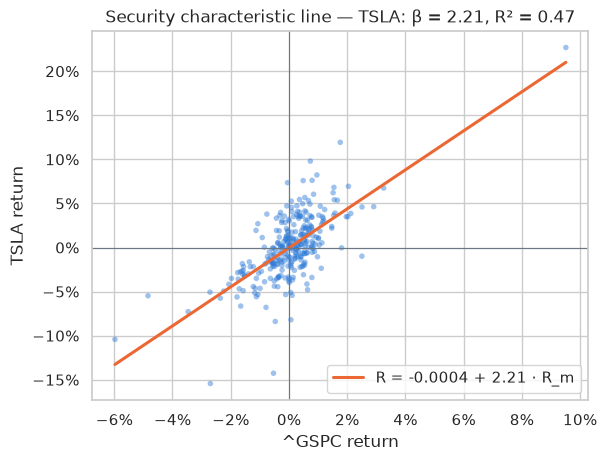

In [4]:
ticker = "TSLA"
asset = returns[ticker]

x_with_const = sm.add_constant(market)
fit = sm.OLS(asset, x_with_const).fit()
alpha, beta = float(fit.params.iloc[0]), float(fit.params.iloc[1])

fig, ax = plt.subplots()
ax.scatter(market, asset, alpha=0.45, s=16, color=BLUE, edgecolor="none")
x_line = np.linspace(market.min(), market.max(), 50)
ax.plot(x_line, alpha + beta * x_line, color=ORANGE, linewidth=2.2,
        label=f"R = {alpha:+.4f} + {beta:.2f} · R_m")
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel(f"{DEFAULT_CONFIG.market_ticker} return")
ax.set_ylabel(f"{ticker} return")
ax.set_title(f"Security characteristic line — {ticker}: β = {beta:.2f}, R² = {fit.rsquared:.2f}")
ax.legend()
plt.show()

## Fitting the SIM across the universe of Assets

`SingleIndexModel.get_models` regresses every ticker in the supplied list against a market proxy column in a single vectorised pass, and caches an `AssetFit` record (rsquared, resid) per ticker on `sim.results`. Alpha and beta are read back with `get_alphas()` and `get_betas()`.

It raises `KeyError` if a requested ticker is not in `returns`, so the list is filtered against the columns yfinance actually returned. Symbols get delisted, renamed, and rate-limited, and the Treasury indices are the usual casualties — the Flask app handles the same problem through `AnalysisResult.dropped_tickers`.

In [5]:
available = [t for t in DEFAULT_CONFIG.all_tickers if t in returns.columns]
dropped = sorted(set(DEFAULT_CONFIG.all_tickers) - set(available))
if dropped:
    print(f"yfinance returned no data for {len(dropped)}: {', '.join(dropped)}")

sim = SingleIndexModel()
sim.get_models(
    tickers=available,
    market_ticker=DEFAULT_CONFIG.market_ticker,
    returns=returns,
)

alphas = pd.Series(sim.get_alphas())
betas = pd.Series(sim.get_betas())
systematic = pd.Series(sim.get_systematic_risks())
firm_specific = pd.Series(sim.get_firm_specific_risks())
r_squared = pd.Series(sim.get_r_squared())

summary = pd.DataFrame({
    "alpha": alphas,
    "beta": betas,
    "R²": r_squared,
    "systematic": systematic,
    "firm_specific": firm_specific,
})
summary.head(10)

,alpha,beta,R²,systematic,firm_specific
AAPL,-0.000233,1.267128,0.557570,0.053498,0.042451
MSFT,-0.000333,0.927645,0.402835,0.028672,0.042504
GOOGL,0.001701,1.089341,0.415660,0.039539,0.055585
AMZN,-0.000011,1.381520,0.526622,0.063594,0.057164
META,-0.000720,1.548122,0.506692,0.079856,0.077747
NVDA,0.000652,1.824125,0.591167,0.110869,0.076673
TSLA,-0.000442,2.212553,0.473757,0.163112,0.181183
AMD,0.003161,2.167635,0.384035,0.156557,0.251106
INTC,0.004290,1.726407,0.198369,0.099308,0.401317
MU,0.004921,2.313160,0.421280,0.178283,0.244911


### regressing the market on itself

By construction, this must give $\alpha = 0$, $\beta = 1$, and $R^2 = 1$ — and it does, within numerical precision.

In [6]:
summary.loc[DEFAULT_CONFIG.market_ticker]

alpha            1.084202e-19
beta             1.000000e+00
R²               1.000000e+00
systematic       3.331959e-02
firm_specific    1.973244e-33
Name: ^GSPC, dtype: float64

## Cross-sectional view

The betas come out **bimodal**, which the textbook picture does not lead you to expect. Around a quarter of the universe sits near zero — mostly the bond and commodity ETFs in the preset (`AGG`, `TLT`, `GLD`, `USO` and friends), which have no reason to track equities — while the largest single group clusters around 1, trailing off into a right tail of high-beta names.

$R^2$ tells the same story from the other side: near zero for the assets the S&P 500 cannot explain, and close to 1 for index trackers like `QQQ`.

The lesson is that "the market" only counts as a common factor for assets that actually belong to it. Fitting a single-index model across asset classes buries that assumption in plain sight.

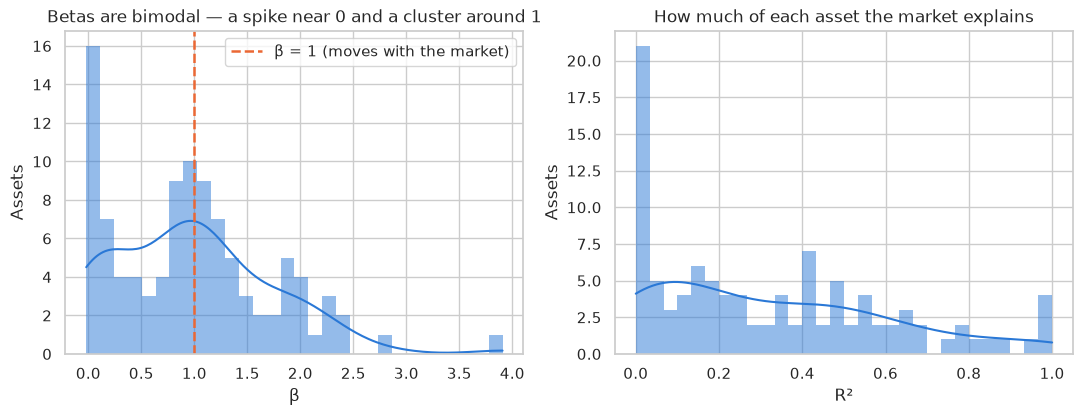

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(betas, bins=30, kde=True, color=BLUE, edgecolor="none", ax=axes[0])
axes[0].axvline(1.0, color=ORANGE, linestyle="--", linewidth=1.8, label="β = 1 (moves with the market)")
axes[0].set_title("Betas are bimodal — a spike near 0 and a cluster around 1")
axes[0].set_xlabel("β")
axes[0].set_ylabel("Assets")
axes[0].legend()

sns.histplot(r_squared, bins=30, kde=True, color=BLUE, edgecolor="none", ax=axes[1])
axes[1].set_title("How much of each asset the market explains")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("Assets")

plt.show()

### Risk decomposition

Stacking systematic and firm-specific risk side by side makes the diversifiable component visible at a glance. Limit the plot to the 30 largest-systematic-risk tickers to keep it readable.

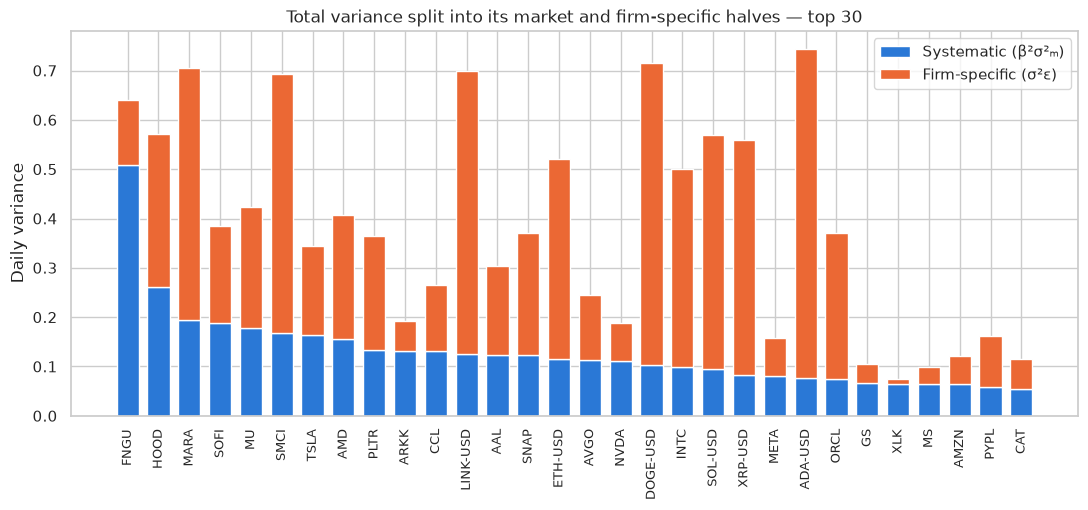

In [8]:
decomposition = (
    pd.DataFrame({"systematic": systematic, "firm_specific": firm_specific})
    .sort_values("systematic", ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(decomposition.index, decomposition["systematic"],
       label="Systematic (β²σ²ₘ)", color=BLUE, width=0.72)
ax.bar(decomposition.index, decomposition["firm_specific"],
       bottom=decomposition["systematic"],
       label="Firm-specific (σ²ε)", color=ORANGE, width=0.72)
ax.set_ylabel("Daily variance")
ax.set_xlabel("")
ax.set_title("Total variance split into its market and firm-specific halves — top 30")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=9)
ax.legend()
plt.show()